In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the data
temperature = np.load('data_t.npy') # Temperature data
pressure = np.load('data_p.npy') # Pressure data
u = np.load('data_u.npy') # U-component data
v = np.load('data_v.npy') # V-component data
w = np.load('data_w.npy') # W-component data
height = np.load('data_h.npy') # Height data

In [3]:
print(u[1,1,0])
print(u.shape)

0.7910142
(180, 360, 51)


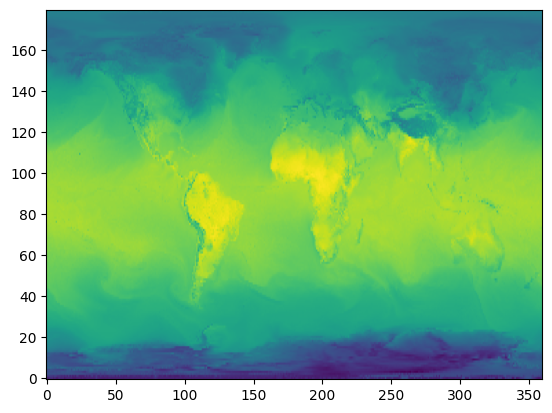

In [4]:
# Very simple: Just show the temperature on the surface
plt.imshow(temperature[:,:,50], origin='lower', aspect='auto')
plt.gca().set_aspect('auto')
plt.show()

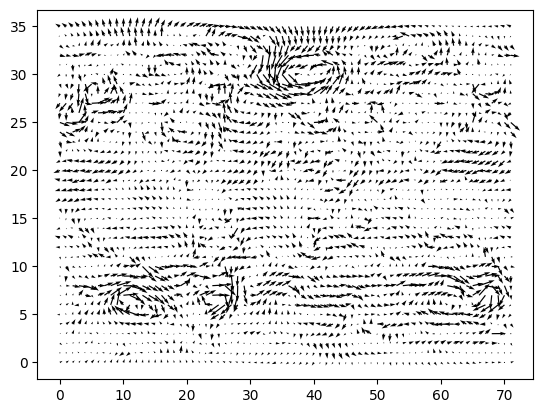

In [5]:
# Show the u- and v-components of the wind at height level 50 (surface) as a simple vector field example
# Use every 5th point to avoid overcrowding
plt.quiver(u[::5,::5,50], v[::5,::5,50])
plt.gca().set_aspect('auto')
plt.show()

Note: you may need to restart the kernel to use updated packages.


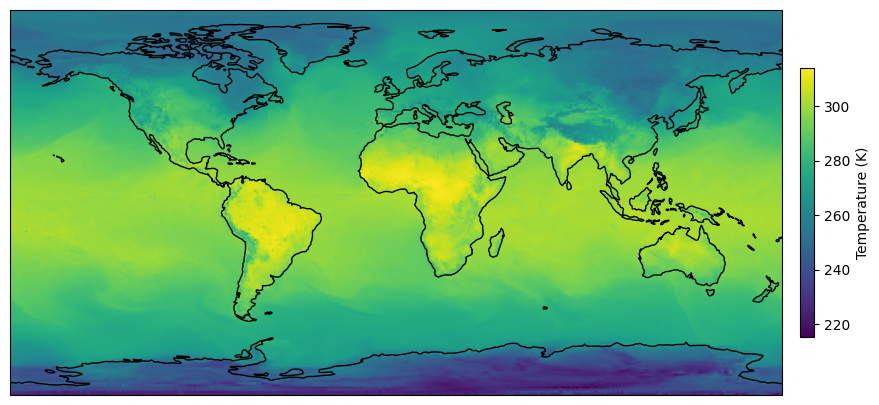

In [6]:
# Plot temperature field as background and overlay with coastlines (you need to install cartopy for this one)
# Also use a PlateCaree projection for proper geographic representation
%pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12,5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot temperature as background
im1 = ax.imshow(temperature[:,:,50], extent=[-180,180,-90,90], origin='lower', aspect='auto', cmap='viridis', transform=ccrs.PlateCarree())
cbar1 = plt.colorbar(im1, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar1.set_label('Temperature (K)')
# Add coastlines
ax.coastlines(resolution='110m', color='black', linewidth=1)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
plt.gca().set_aspect('auto')
plt.show()

In [7]:

# If you haven't installed pyvista yet, run pip install trame pyvista trame-vtk trame-vuetify
# For interactive visualization: pip install "ipywidgets==7.7.2"
import pyvista as pv
# pv.set_jupyter_backend('trame') 

# Prepare grid dimensions
u_sub = u[::5, ::10, ::2]
v_sub = v[::5, ::10, ::2]
w_sub = w[::5, ::10, ::2]
height_sub = height[::5, ::10, ::2]/np.max(height) *10 # Scale height for better visualization
nx, ny, nz = u_sub.shape
print(f"Grid dimensions: nx={nx}, ny={ny}, nz={nz}")

# Create the meshgrid for coordinates
x, y, z = np.meshgrid(np.arange(nx), np.arange(ny), np.arange(nz), indexing='ij')
z = height_sub  # Use height data for z-coordinates

# Flatten arrays for pyvista
points = np.column_stack((x.ravel(), y.ravel(), z.ravel()))
vectors = np.column_stack((u_sub.ravel(), v_sub.ravel(), w_sub.ravel()))

# Create pyvista StructuredGrid
grid = pv.StructuredGrid()
grid.points = points
grid.dimensions = (nx, ny, nz)
grid["vectors"] = vectors

# Plot the vector field
plotter = pv.Plotter(notebook=True)
plotter.add_arrows(grid.points, grid["vectors"], mag=0.03, color="blue")
#plotter.show(jupyter_backend="static")
plotter.show()

Grid dimensions: nx=36, ny=36, nz=26


Widget(value='<iframe src="http://localhost:9998/index.html?ui=P_0x26fdcdeea10_0&reconnect=auto" class="pyvist…

In [ ]:
import numpy as np
import pyvista as pv
from ipywidgets import interact, IntSlider



u_grid = np.load('data_u.npy')
v_grid = np.load('data_v.npy')
w_grid = np.load('data_w.npy')
t_grid = np.load('data_t.npy') 
print("Data Loaded.")



Data Loaded.


In [11]:
def get_velocity_at(position):
    x, y, z = position
    nx, ny, nz = u_grid.shape
    if x < 0 or x >= nx-1 or y < 0 or y >= ny-1 or z < 0 or z >= nz-1:
        return np.array([0.0, 0.0, 0.0])
        
    x0, y0, z0 = int(x), int(y), int(z)
    x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
    xd, yd, zd = x-x0, y-y0, z-z0
    
    def interp(grid):
        c00 = grid[x0, y0, z0]*(1-xd) + grid[x1, y0, z0]*xd
        c01 = grid[x0, y0, z1]*(1-xd) + grid[x1, y0, z1]*xd
        c10 = grid[x0, y1, z0]*(1-xd) + grid[x1, y1, z0]*xd
        c11 = grid[x0, y1, z1]*(1-xd) + grid[x1, y1, z1]*xd
        c0 = c00*(1-yd) + c10*yd
        c1 = c01*(1-yd) + c11*yd
        return c0*(1-zd) + c1*zd

    return np.array([interp(u_grid), interp(v_grid), interp(w_grid) * 50])

In [12]:
def compute_streamline(seed, step_size=0.5, max_steps=500):
    path = [seed]
    curr = np.array(seed)
    
    for _ in range(max_steps):
        vel = get_velocity_at(curr)
        mag = np.linalg.norm(vel)
        if mag == 0: break 
        
        direction = vel / mag 
        # PHYSICS FIX: Swap U (East) -> Lon, V (North) -> Lat
        step_vector = np.array([direction[1], direction[0], direction[2]])
        
        next_pos = curr + (step_vector * step_size)
        path.append(next_pos)
        curr = next_pos
        
    return np.array(path)

In [ ]:
def plot_interactive(lat_seed, lon_seed, alt_seed, view_elev, view_azim):
    
    # Setup Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Draw Map
    temp_slice = t_grid[:, :, 0]
    X, Y = np.meshgrid(np.arange(temp_slice.shape[1]), np.arange(temp_slice.shape[0]))
    ax.contourf(X, Y, temp_slice, zdir='z', offset=0, cmap='terrain', alpha=0.6)
    
    # Draw Streamline
    seed = [lat_seed, lon_seed, alt_seed]
    streamline = compute_streamline(seed, step_size=1.0)
    
    if len(streamline) > 1:
        ax.plot(streamline[:, 1], streamline[:, 0], streamline[:, 2], color='black', linewidth=3)
        ax.scatter(seed[1], seed[0], seed[2], color='red', s=100, label='Start')
        ax.scatter(streamline[-1, 1], streamline[-1, 0], streamline[-1, 2], color='blue', s=50)

    # Formatting
    ax.set_title(f"Interactive Tool (Use Camera Sliders below)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_zlabel("Altitude")
    ax.set_xlim(0, 360); ax.set_ylim(0, 180); ax.set_zlim(0, 50)
    
   
    ax.view_init(elev=view_elev, azim=view_azim)
    
    
    plt.show()


print("Creating interactive tool.")

interact(plot_interactive, 
         # Seed Controls
         lat_seed=IntSlider(min=10, max=170, step=5, value=90, description='Lat (N/S)'),
         lon_seed=IntSlider(min=10, max=350, step=5, value=180, description='Lon (E/W)'),
         alt_seed=IntSlider(min=1, max=45, step=1, value=15, description='Height'),
         
         # Camera Controls
         view_elev=IntSlider(min=0, max=90, step=5, value=60, description='View Up/Down'),
         view_azim=IntSlider(min=-180, max=180, step=10, value=-90, description='Rotate View'))

Creating Interactive Tool with Camera Controls...


interactive(children=(IntSlider(value=90, description='Lat (N/S)', max=170, min=10, step=5), IntSlider(value=1…

<function __main__.plot_interactive(lat_seed, lon_seed, alt_seed, view_elev, view_azim)>

In [15]:

def plot_3d_pyvista(lat, lon, alt):
    p = pv.Plotter(notebook=True, window_size=[800, 600])
    p.set_background("white")

    # A. Floor Map
    dims = (t_grid.shape[1], t_grid.shape[0], 1)
    floor = pv.ImageData(dimensions=dims, spacing=(1, 1, 1), origin=(0, 0, 0))
    floor.point_data["Temperature"] = t_grid[:, :, 0].ravel()
    p.add_mesh(floor, cmap="terrain", opacity=0.6, show_scalar_bar=False)

    # B. Streamline
    seed = [lat, lon, alt]
    points = compute_streamline(seed, step_size=1.0)

    if len(points) > 1:
        # Swap for plotting: (Lat, Lon, Alt) -> (Lon, Lat, Alt)
        plot_points = np.column_stack((points[:, 1], points[:, 0], points[:, 2]))
        
        # Draw Line (Clean Black Line)
        line = pv.lines_from_points(plot_points)
        p.add_mesh(line, color="black", line_width=3, label="Streamline")
        
        # Start/End Dots
        p.add_mesh(pv.Sphere(radius=2, center=plot_points[0]), color="red", label="Start")
        p.add_mesh(pv.Sphere(radius=2, center=plot_points[-1]), color="blue")

    p.add_axes()
    p.camera_position = 'iso'
    
    p.show()


print("Launching Final Tool...")
interact(plot_3d_pyvista, 
         lat=IntSlider(min=10, max=170, step=5, value=90, description='Latitude'),
         lon=IntSlider(min=10, max=350, step=5, value=180, description='Longitude'),
         alt=IntSlider(min=1, max=45, step=1, value=15, description='Height'));

Launching Final Tool...


interactive(children=(IntSlider(value=90, description='Latitude', max=170, min=10, step=5), IntSlider(value=18…